In [1]:
#import and formatting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.size'] = 12
sns.set(style="whitegrid", context="talk")

file_path = "Source_Data_CXCL12_placenta.xlsx"
df = pd.read_excel(file_path, sheet_name="Fig_5B")  

NameError: name 'annotate_stats' is not defined

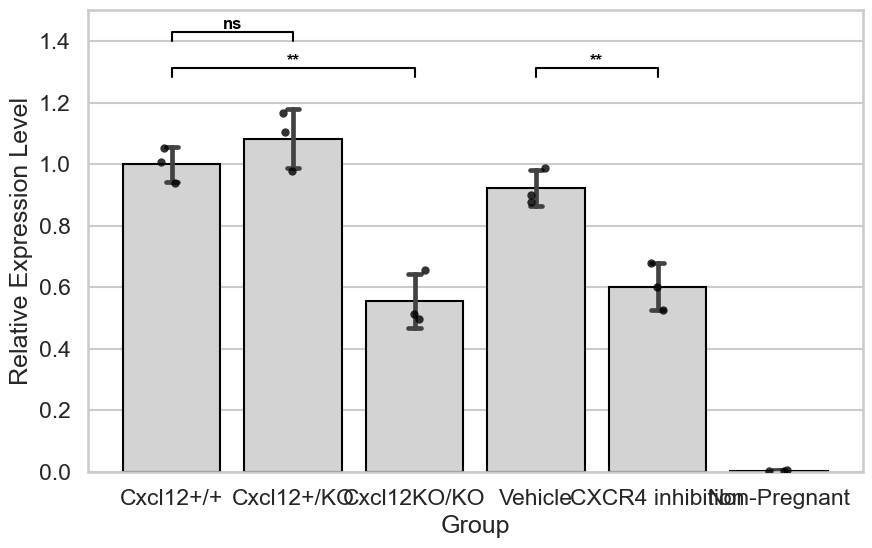

In [2]:
df_melted = df.melt(var_name='Group', value_name='Relative Expression Level').dropna()

group_order = [
    'Cxcl12+/+', 
    'Cxcl12+/KO', 
    'Cxcl12KO/KO', 
    'Vehicle', 
    'CXCR4 inhibition', 
    'Non-Pregnant'
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_melted, x='Group', y='Relative Expression Level', 
    ax=ax, color='#D3D3D3', edgecolor='black', errorbar='sd', capsize=0.1,
    order=group_order  
)

sns.stripplot(
    data=df_melted, x='Group', y='Relative Expression Level', 
    ax=ax, color='#000000', alpha=0.8, jitter=True, size=6,
    order=group_order  
)

def annotate_ttest(group1, group2, y_pos, height=0.03):
    data1 = df_melted[df_melted['Group'] == group1]['Relative Expression Level']
    data2 = df_melted[df_melted['Group'] == group2]['Relative Expression Level']
    
    t_stat, p_val = stats.ttest_ind(data1, data2, nan_policy='omit')
    draw_bracket_and_text(group1, group2, p_val, y_pos, height)

def annotate_anova_tukey(group1, group2, all_three_groups, y_pos, height=0.03):
    g1_data = df_melted[df_melted['Group'] == all_three_groups[0]]['Relative Expression Level']
    g2_data = df_melted[df_melted['Group'] == all_three_groups[1]]['Relative Expression Level']
    g3_data = df_melted[df_melted['Group'] == all_three_groups[2]]['Relative Expression Level']
    
    f_stat, p_anova = stats.f_oneway(g1_data, g2_data, g3_data)
    
    if p_anova < 0.05:
        tukey_results = stats.tukey_hsd(g1_data, g2_data, g3_data)
        
        idx1 = all_three_groups.index(group1)
        idx2 = all_three_groups.index(group2)
        
        p_val = tukey_results.pvalue[idx1, idx2]
    else:
        p_val = 1.0 #
        
    draw_bracket_and_text(group1, group2, p_val, y_pos, height)

def draw_bracket_and_text(group1, group2, p_val, y_pos, height):
    """Helper function to draw the actual bracket and stars"""
    if p_val < 0.001: sig = '***'
    elif p_val < 0.01: sig = '**'
    elif p_val < 0.05: sig = '*'
    else: sig = 'ns'
        
    x1, x2 = group_order.index(group1), group_order.index(group2)
    
    ax.plot([x1, x1, x2, x2], [y_pos, y_pos+height, y_pos+height, y_pos], lw=1.5, c='black')
    ax.text((x1+x2)*.5, y_pos+height, sig, ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')

max_y = df_melted['Relative Expression Level'].max()
step = max_y * 0.1

# genetic comparison
genotype_groups = ['Cxcl12+/+', 'Cxcl12+/KO', 'Cxcl12KO/KO']

annotate_anova_tukey('Cxcl12+/+', 'Cxcl12KO/KO', genotype_groups, y_pos=max_y + step)
annotate_anova_tukey('Cxcl12+/+', 'Cxcl12+/KO', genotype_groups, y_pos=max_y + (step * 2))

# pharmacological comparison
annotate_ttest('Vehicle', 'CXCR4 inhibition', y_pos=max_y + step)

annotate_stats('Cxcl12+/+', 'Cxcl12KO/KO', y_pos=max_y + step)
annotate_stats('Vehicle', 'CXCR4 inhibition', y_pos=max_y + step)

ax.set_title('Normalized Gene Expression by Group', fontsize=15, pad=20)
ax.set_ylabel('Relative Expression Level', fontsize=12)

ax.set_ylim(0, max_y + step * 4) 

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()